# 06 · Reconocimiento de Entidades Nombradas (NER)
**Proyecto:** Salud en la esfera pública — análisis de tweets en español  
**Equivalente original:** `8_NER.ipynb`

---

### Diferencias con el paper

| Aspecto | Paper | Este notebook |
|---|---|---|
| Unidad de análisis | `texto_chunk` de fragmentos | `Texto_limpio` de tweets |
| NER sobre | Corpus completo + subcorpus ciencia | Corpus completo + subcorpus salud |
| Filtro de co-ocurrencia | Fragmentos con palabra 'ciencia*' | Tweets con palabra 'salud*' |
| Metadatos | Autor, Diario, Año | Author_Normalized, Entidad, Año |
| Grafo | Red 'ciencia' - entidades por año | Red 'salud' - entidades por año |

**Entradas:**
- `resultadosPropios/corpus_cleaned.parquet`
- `resultadosPropios/salud_tweets_final.parquet`

**Salidas:**
- `resultadosPropios/general_ner.parquet` — NER sobre corpus completo
- `resultadosPropios/salud_ner.parquet` — NER sobre subcorpus de salud
- `resultadosPropios/entidades_salud.xlsx` — tablas de frecuencias
- `resultadosPropios/fig_frecuencia_por_tipo.png`
- `resultadosPropios/fig_grafo_salud_{año}.png` — grafos por año


## 0 · Configuración

In [15]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento')

COL_AUTOR   = 'Author_Normalized'
COL_FECHA   = 'Fecha'
COL_ENTIDAD = 'Entidad'

# Modelo NER (mismo que el paper)
NER_MODEL = 'Babelscape/wikineural-multilingual-ner'

# Entidades genéricas a excluir del grafo
ENTIDADES_EXCLUIR = [
    'Colombia', 'Estado', 'Gobierno', 'Mundo', 'Nacion',
    'America Latina', 'Ciudadanos', 'Nacional', 'Personas',
    'Organizaciones', 'Ministerio', 'Salud',
]

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')
print(f'  Modelo NER     : {NER_MODEL}')


[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento
  Modelo NER     : Babelscape/wikineural-multilingual-ner


## 1 · Imports y carga de datos

In [16]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# Equivalente a celdas 0-3 del paper
# ============================================================
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import pandas as pd
import numpy as np
from collections import Counter
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import warnings
warnings.filterwarnings('ignore')

device = 0 if torch.cuda.is_available() else -1
print(f'Dispositivo NER : {"GPU" if device == 0 else "CPU"}')

# Corpus completo
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus[COL_FECHA] = pd.to_datetime(corpus[COL_FECHA], errors='coerce')
corpus['Anio'] = corpus[COL_FECHA].dt.year

# Subcorpus de comportamientos — merge metadatos desde corpus
tweets_comp  = pd.read_parquet(DATA_PROCESSED / 'comportamiento_tweets_final.parquet')
tweets_comp  = tweets_comp.merge(
    corpus[['id_doc', COL_AUTOR, COL_ENTIDAD, COL_FECHA, 'Anio', 'Texto_limpio']],
    on='id_doc', how='left'
)
tweets_comp[COL_FECHA]  = pd.to_datetime(tweets_comp[COL_FECHA], errors='coerce')

print(f'Corpus completo    : {len(corpus):,} tweets')
print(f'Subcorpus comp.    : {len(tweets_comp):,} tweets')
corpus.head(2)


Dispositivo NER : GPU
Corpus completo    : 151,424 tweets
Subcorpus comp.    : 2,804 tweets


,id_doc,Author_Normalized,Author Name,Fecha,Date,anio,mes,anio_mes,Location,Number of Likes,Number of Retweets,Hashtags,Mentions,Sentimiento,Polaridad,Entidad,Content,Texto_limpio,n_palabras,Anio
0,1,@treporta,Telemetro Reporta,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,NaN,0.0,0.0,['#panama'],[],otro,Neutra,"Noticias locales, nacionales o globales",VÍDEO| Reos que no están contagiados con COVID...,VDEO Reos que no están contagiados con COVID19...,15,2020
1,2,@annytak21,ANNA KAROLYNNA,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,NaN,0.0,0.0,[],"['@ivanduque', '@jaimepumarejo']",otro,Negativa,Sin descripción,@IvanDuque @jaimepumarejo ya se enteraron de l...,ya se enteraron de la muerte supestamente por ...,24,2020


## 2 · Cargar modelo NER
Mismo modelo que el paper: `Babelscape/wikineural-multilingual-ner`.  
Reconoce PER (personas), ORG (organizaciones), LOC (lugares) y MISC.


In [17]:
# ============================================================
# CELL 2 — CARGAR MODELO NER
# Equivalente a celda 5 del paper
# ============================================================

tokenizer    = AutoTokenizer.from_pretrained(NER_MODEL)
model_ner    = AutoModelForTokenClassification.from_pretrained(NER_MODEL)
ner_pipeline = pipeline(
    'ner',
    model=model_ner,
    tokenizer=tokenizer,
    aggregation_strategy='simple',   # reemplaza grouped_entities=True (deprecated)
    device=device,
)
print(f'Modelo NER cargado: {NER_MODEL}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: Babelscape/wikineural-multilingual-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo NER cargado: Babelscape/wikineural-multilingual-ner


## 3 · Función de extracción de entidades
Réplica exacta de `extraer_entidades()` del paper.  
Para tweets la longitud es corta (~25 palabras), así que el bucle de  
fragmentación raramente se activa, pero se mantiene por robustez.


In [18]:
# ============================================================
# CELL 3 — FUNCION NER
# Replica exacta de extraer_entidades() del paper (celda 6)
# ============================================================

def extraer_entidades(texto: str, max_palabras: int = 400) -> list:
    """
    Extrae entidades nombradas de un texto.
    Divide en fragmentos si supera max_palabras (limite del modelo).
    Devuelve lista de tuplas (tipo_entidad, texto_entidad).
    Replica exacta de extraer_entidades() del paper.
    """
    entidades = []
    try:
        palabras = str(texto).split()
        for i in range(0, len(palabras), max_palabras):
            fragmento  = ' '.join(palabras[i : i + max_palabras])
            resultados = ner_pipeline(fragmento)
            for r in resultados:
                tipo   = r.get('entity_group', '').strip()
                nombre = r.get('word', '').strip()
                if tipo and nombre:
                    entidades.append((tipo, nombre))
    except Exception as e:
        print(f'Error procesando texto: {e}')
    return entidades

# Prueba rapida
print(extraer_entidades('El Ministerio de Salud de Colombia anuncio nuevas medidas.'))


[('ORG', 'Ministerio de Salud de Colombia')]


## 4 · NER sobre el corpus completo
Equivalente a las celdas 9-10 del paper.  
⚠️ Este paso puede tardar varios minutos dependiendo del tamaño del corpus.


In [19]:
# ============================================================
# CELL 4 — NER CORPUS COMPLETO
# Equivalente a celdas 9-10 del paper
# ============================================================

RUTA_GENERAL_NER = DATA_PROCESSED / 'general_ner.parquet'

if RUTA_GENERAL_NER.exists():
    print(f'Archivo encontrado, cargando: {RUTA_GENERAL_NER}')
    resultado_general = pd.read_parquet(RUTA_GENERAL_NER)
else:
    print('Extrayendo entidades del corpus completo...')
    tqdm.pandas(desc='NER corpus')
    corpus['entidades'] = corpus['Texto_limpio'].progress_apply(extraer_entidades)

    resultado_general = corpus[['id_doc', COL_AUTOR, COL_FECHA, 'Anio',
                                'Texto_limpio', 'entidades']].copy()
    resultado_general.to_parquet(RUTA_GENERAL_NER, index=False)
    print(f'[GUARDADO] general_ner.parquet ({len(resultado_general):,} tweets)')

print(f'Tweets con NER: {len(resultado_general):,}')
resultado_general.head(2)


Archivo encontrado, cargando: C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento\general_ner.parquet
Tweets con NER: 151,424


,id_doc,Author_Normalized,Fecha,Anio,Texto_limpio,entidades
0,1,@treporta,2020-06-03,2020,VDEO Reos que no están contagiados con COVID19...,"[[LOC, Santiago], [LOC, Ifarhu], [LOC, Panamá]]"
1,2,@annytak21,2020-06-03,2020,ya se enteraron de la muerte supestamente por ...,"[[PER, Sandra Correa]]"


## 5 · NER sobre el subcorpus de salud
Equivalente a las celdas 11-13 del paper (NER sobre fragmentos de ciencia).  
Aquí lo aplicamos sobre los tweets con mención de salud.


In [20]:
# ============================================================
# CELL 5 — NER SUBCORPUS SALUD
# Equivalente a celdas 11-13 del paper
# ============================================================

RUTA_COMP_NER  = DATA_PROCESSED / 'comportamiento_ner.parquet'

if RUTA_COMP_NER.exists():
    print(f'Archivo encontrado, cargando: {RUTA_COMP_NER}')
    resultado_comp  = pd.read_parquet(RUTA_COMP_NER)
else:
    print('Extrayendo entidades del subcorpus de comportamientos...')
    tqdm.pandas(desc='NER comportamientos')
    tweets_comp['entidades']  = tweets_comp['Texto_limpio'].progress_apply(
        extraer_entidades
    )
    resultado_comp  = tweets_comp[[
        'id_doc', COL_AUTOR, 'Fecha', 'Anio',
        'categoria_detectada', 'Texto_limpio', 'entidades'
    ]].copy()
    resultado_comp.to_parquet(RUTA_COMP_NER, index=False)
    print(f'[GUARDADO] comportamiento_ner.parquet ({len(resultado_comp):,} tweets)')

print(f'Tweets de comp. con NER: {len(resultado_comp):,}')
resultado_comp.head(2)


Archivo encontrado, cargando: C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento\comportamiento_ner.parquet
Tweets de comp. con NER: 2,804


,id_doc,Author_Normalized,Fecha,Anio,categoria_detectada,Texto_limpio,entidades
0,17,@elima2219,2020-06-03,2020,Comp_Evitar_reuniones,A esas horas el covid19 se queda en la casa mi...,"[[MISC, covid19]]"
1,67,@cmalcagmailcom1,2020-06-03,2020,Comp_Etiqueta_tos_panuelo,Los vendedores de balones de oxígeno y las pla...,"[[MISC, COVID19]]"


## 6 · Análisis de frecuencias de entidades
Equivalente a las celdas 18-23 del paper.


In [21]:
# ============================================================
# CELL 6 — APLANAR Y CONTAR ENTIDADES
# Equivalente a celdas 18-23 del paper
# ============================================================

def aplanar_entidades(df_ner: pd.DataFrame) -> pd.DataFrame:
    """Convierte lista de tuplas por fila a un DataFrame plano."""
    todas = []
    for _, row in df_ner.iterrows():
        for tipo, nombre in row['entidades']:
            if isinstance(tipo, str) and isinstance(nombre, str):
                todas.append({
                    'id_doc': row['id_doc'],
                    'Tipo'  : tipo,
                    'Entidad': nombre.strip(),
                })
    return pd.DataFrame(todas)

# Aplanar subcorpus de comportamientos
df_plano = aplanar_entidades(resultado_comp)
print(f'Entidades extraidas (comp.): {len(df_plano):,}')
print(f'Tipos encontrados          : {df_plano["Tipo"].unique()}')

# Frecuencia por tipo
freq_tipo = (
    df_plano.groupby('Tipo').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)
print()
print(freq_tipo.to_string(index=False))


Entidades extraidas (comp.): 4,324
Tipos encontrados          : <ArrowStringArray>
['MISC', 'LOC', 'ORG', 'PER']
Length: 4, dtype: str

Tipo  Frecuencia
MISC        2568
 LOC        1077
 ORG         450
 PER         229


## 7 · Gráfico de frecuencia por tipo de entidad

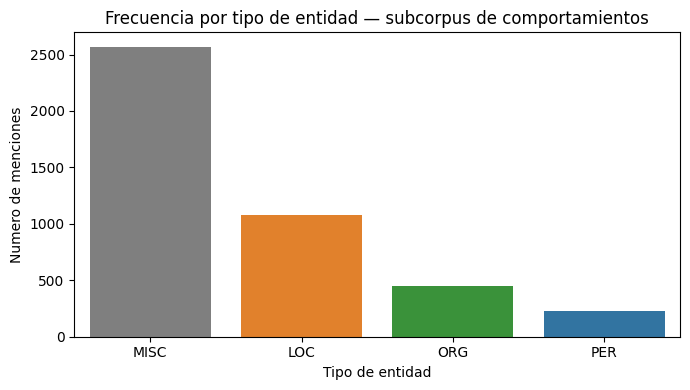

[GUARDADO] fig_frecuencia_por_tipo.png


In [22]:
# ============================================================
# CELL 7 — GRAFICO POR TIPO
# Replica de celda 21 del paper
# ============================================================

palette = {'PER': '#1f77b4', 'ORG': '#2ca02c', 'LOC': '#ff7f0e', 'MISC': '#7f7f7f'}

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=freq_tipo, x='Tipo', y='Frecuencia',
            palette=[palette.get(t, '#999') for t in freq_tipo['Tipo']], ax=ax)
ax.set_title('Frecuencia por tipo de entidad — subcorpus de comportamientos')
ax.set_ylabel('Numero de menciones')
ax.set_xlabel('Tipo de entidad')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_frecuencia_por_tipo.png', dpi=300)
plt.show()
print('[GUARDADO] fig_frecuencia_por_tipo.png')


## 8 · Top entidades por tipo
Equivalente a las celdas 22-23 del paper.



Top 10 — LOC:
            Entidad  Frecuencia
             Madrid          51
              China          31
       Barranquilla          15
          Andalucía          14
           Colombia          14
Comunidad de Madrid          14
               Cali          11
             México           8
             Boyacá           7
         California           7

Top 10 — MISC:
Entidad  Frecuencia
COVID19         266
Covid19         255
     Co         143
     CO         128
  Covid         107
  COVID          92
     co          57
   ##19          32
covid19          30
  covid          29

Top 10 — ORG:
            Entidad  Frecuencia
                OMS          20
                UCI          17
                 Co          15
              Covid          12
            Covid19          11
               ##19           7
              ##vid           5
          Comunidad           5
Ministerio de Salud           5
                CDC           4

Top 10 — PER:
              E

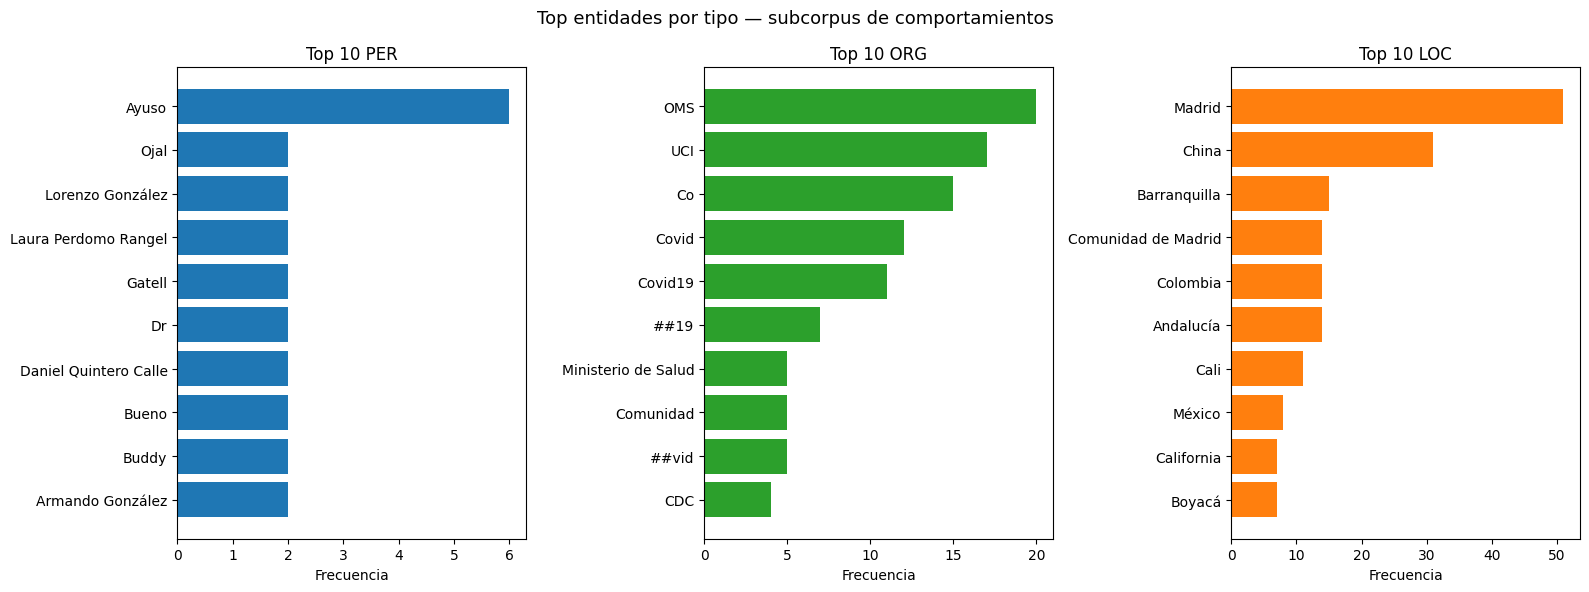

[GUARDADO] fig_top_entidades_por_tipo.png


In [23]:
# ============================================================
# CELL 8 — TOP ENTIDADES POR TIPO
# Equivalente a celdas 22-23 del paper
# ============================================================

top_por_tipo = (
    df_plano.groupby(['Tipo', 'Entidad']).size()
    .reset_index(name='Frecuencia')
    .sort_values(['Tipo', 'Frecuencia'], ascending=[True, False])
)
top10 = top_por_tipo.groupby('Tipo').head(10)

for tipo in top10['Tipo'].unique():
    subset = top10[top10['Tipo'] == tipo]
    print(f'\nTop 10 — {tipo}:')
    print(subset[['Entidad', 'Frecuencia']].to_string(index=False))

# Grafico por tipo
tipos_principales = ['PER', 'ORG', 'LOC']
fig, axes = plt.subplots(1, len(tipos_principales), figsize=(16, 6))

for ax, tipo in zip(axes, tipos_principales):
    subset = top_por_tipo[top_por_tipo['Tipo'] == tipo].head(10)
    if subset.empty:
        ax.set_visible(False)
        continue
    subset = subset.sort_values('Frecuencia', ascending=True)
    ax.barh(subset['Entidad'], subset['Frecuencia'],
            color=palette.get(tipo, '#999'))
    ax.set_title(f'Top 10 {tipo}')
    ax.set_xlabel('Frecuencia')

plt.suptitle('Top entidades por tipo — subcorpus de comportamientos', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_entidades_por_tipo.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_entidades_por_tipo.png')


## 9 · Co-ocurrencias entre comportamientos protectores
Pares de comportamientos que aparecen juntos en el mismo tweet.

In [24]:
# ============================================================
# CELL 9 — COOCURRENCIAS ENTRE COMPORTAMIENTOS PROTECTORES
# ============================================================
import unicodedata, itertools

comportamientos_dict = {
    'Lavado_manos'        : ['lavado de manos', 'lavar manos', 'lavarse manos',
                              'lavate las manos', 'agua y jabon', 'higiene de manos'],
    'Desinfectante'       : ['gel desinfectante', 'gel antibacterial', 'alcohol gel',
                              'desinfectante de manos', 'gel hidroalcoholico'],
    'Mascarilla'          : ['mascarilla', 'tapabocas', 'cubrebocas', 'kn95', 'n95',
                              'ffp2', 'barbijo'],
    'Etiqueta_tos_codo'   : ['toser en el codo', 'estornudar en el codo',
                              'taparse al toser', 'etiqueta respiratoria'],
    'Etiqueta_tos_panuelo': ['toser en panuelo', 'estornudar en panuelo',
                              'panuelo desechable'],
    'Distanciamiento'     : ['distanciamiento social', 'distancia social',
                              'guardar distancia', 'mantener distancia',
                              'dos metros', 'distancia de seguridad'],
    'Evitar_reuniones'    : ['evitar reuniones', 'quedarse en casa', 'quedateencasa',
                              'confinamiento', 'cuarentena', 'aislamiento social'],
}

def norm_txt(texto):
    if not isinstance(texto, str):
        return ""
    t = texto.lower()
    t = unicodedata.normalize("NFD", t)
    return "".join(c for c in t if unicodedata.category(c) != "Mn")

def comps_en_tweet(texto):
    t = norm_txt(texto)
    encontrados = []
    for comp, variantes in comportamientos_dict.items():
        for v in variantes:
            if norm_txt(v) in t:
                encontrados.append(comp)
                break
    return sorted(set(encontrados))

resultado_comp['comps_detectados'] = resultado_comp['Texto_limpio'].map(comps_en_tweet)
df_multi = resultado_comp[resultado_comp['comps_detectados'].map(len) >= 2].copy()
print(f'Tweets con >= 2 comportamientos: {len(df_multi):,}')

pares_list = []
for _, fila in df_multi.iterrows():
    anio = fila.get('Anio')
    for a, b in itertools.combinations(fila['comps_detectados'], 2):
        pares_list.append({'Anio': anio, 'Comp_A': a, 'Comp_B': b, 'Par': f'{a} + {b}'})

df_pares = pd.DataFrame(pares_list)
freq_cooc = (df_pares.groupby('Par').size()
             .reset_index(name='frecuencia')
             .sort_values('frecuencia', ascending=False))
freq_cooc_anio = (df_pares.groupby(['Anio','Par']).size()
                  .reset_index(name='frecuencia')
                  .sort_values(['Anio','frecuencia'], ascending=[True,False]))
print(f'Pares distintos: {len(freq_cooc):,}')
print('\nTop 10 pares co-ocurrentes:')
print(freq_cooc.head(10).to_string(index=False))


Tweets con >= 2 comportamientos: 141
Pares distintos: 14

Top 10 pares co-ocurrentes:
                               Par  frecuencia
         Lavado_manos + Mascarilla          45
      Distanciamiento + Mascarilla          41
     Evitar_reuniones + Mascarilla          39
Distanciamiento + Evitar_reuniones          16
        Desinfectante + Mascarilla          11
    Distanciamiento + Lavado_manos          11
   Evitar_reuniones + Lavado_manos           9
  Desinfectante + Evitar_reuniones           4
      Desinfectante + Lavado_manos           3
   Desinfectante + Distanciamiento           2


## 10 · Pares de comportamientos por año
Frecuencia de co-ocurrencia anual.

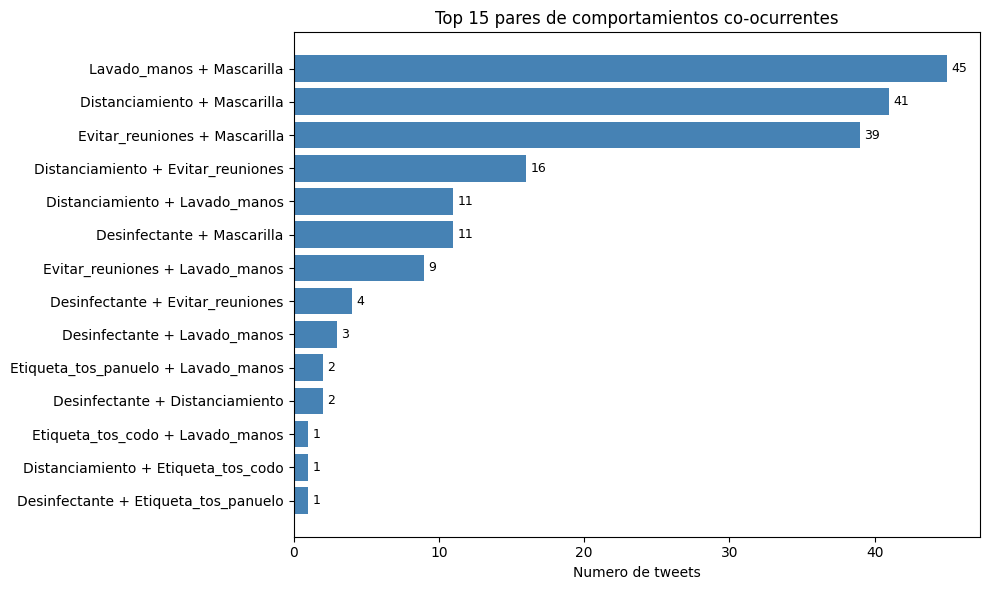

[GUARDADO] fig_coocurrencias_comportamientos.png


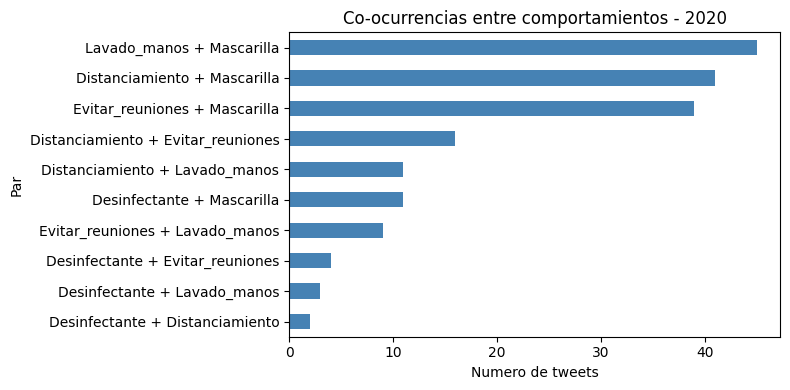

[GUARDADO] fig_coocurrencias_comportamiento_2020.png


In [25]:
# ============================================================
# CELL 10 — BARRAS DE CO-OCURRENCIA
# ============================================================
top15 = freq_cooc.head(15).sort_values("frecuencia", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15["Par"], top15["frecuencia"], color="steelblue")
for i, v in enumerate(top15["frecuencia"]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
ax.set_title("Top 15 pares de comportamientos co-ocurrentes")
ax.set_xlabel("Numero de tweets")
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_coocurrencias_comportamientos.png', dpi=300)
plt.show()
print('[GUARDADO] fig_coocurrencias_comportamientos.png')

anios = sorted(df_pares['Anio'].dropna().unique())
for anio in anios:
    top = freq_cooc_anio[freq_cooc_anio["Anio"] == anio].head(10)
    if top.empty: continue
    fig, ax = plt.subplots(figsize=(8, 4))
    top.sort_values("frecuencia", ascending=True).plot.barh(
        x="Par", y="frecuencia", ax=ax, legend=False, color="steelblue")
    ax.set_title(f"Co-ocurrencias entre comportamientos - {int(anio)}")
    ax.set_xlabel("Numero de tweets")
    plt.tight_layout()
    plt.savefig(DATA_PROCESSED / f'fig_coocurrencias_comportamiento_{int(anio)}.png', dpi=300)
    plt.show()
    print(f'[GUARDADO] fig_coocurrencias_comportamiento_{int(anio)}.png')


## 11 · Grafo de red: co-ocurrencias entre comportamientos
Nodos = comportamientos, arcos = co-ocurrencia en el mismo tweet.

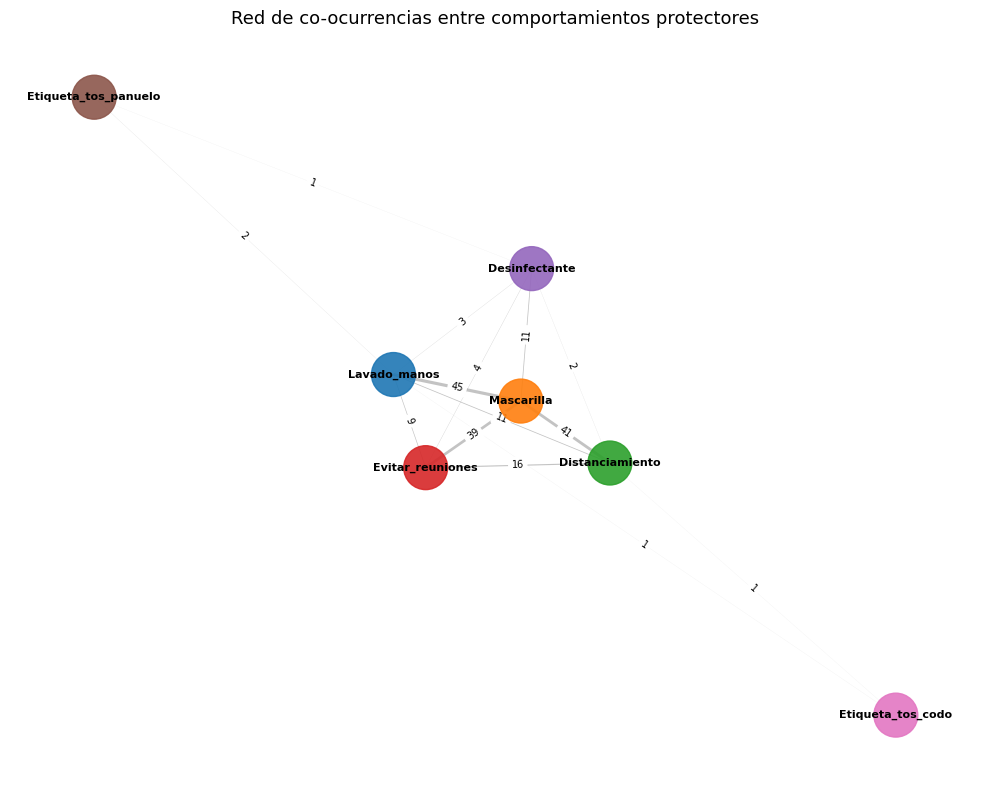

[GUARDADO] fig_grafo_coocurrencias_comportamientos.png


In [26]:
# ============================================================
# CELL 11 — GRAFO DE RED
# ============================================================
G = nx.Graph()
for _, row in freq_cooc.head(20).iterrows():
    a, b = row["Par"].split(" + ")
    peso = row["frecuencia"]
    for nd in (a, b):
        if nd not in G:
            G.add_node(nd)
    if G.has_edge(a, b):
        G[a][b]["weight"] += peso
    else:
        G.add_edge(a, b, weight=peso)

palette = plt.cm.tab10.colors
node_colors = {n: palette[i % 10] for i, n in enumerate(G.nodes())}
pos = nx.spring_layout(G, k=1.5, seed=42)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.5,
    width=[d["weight"] * 0.05 for (_, _, d) in G.edges(data=True)],
    edge_color="#888888")
nx.draw_networkx_nodes(G, pos,
    node_color=[node_colors[n] for n in G.nodes()],
    node_size=1000, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
edge_labels = {(u, v): d["weight"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Red de co-ocurrencias entre comportamientos protectores", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_grafo_coocurrencias_comportamientos.png', dpi=300)
plt.show()
print('[GUARDADO] fig_grafo_coocurrencias_comportamientos.png')


## 12 · Guardar tablas

In [27]:
# ============================================================
# CELL 12 — GUARDAR TABLAS
# Equivalente a celda 24 del paper
# ============================================================

resumen = (
    df_plano.groupby(['Tipo', 'Entidad']).size()
    .reset_index(name='Frecuencia')
    .sort_values(['Tipo', 'Frecuencia'], ascending=[True, False])
)

ruta_excel = DATA_PROCESSED / 'entidades_comportamiento.xlsx'
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    freq_tipo.to_excel(writer,    sheet_name='Frecuencia_por_tipo',  index=False)
    top10.to_excel(writer,        sheet_name='Top10_por_tipo',       index=False)
    resumen.to_excel(writer,      sheet_name='Todas_entidades',      index=False)
    freq_cooc.to_excel(writer,    sheet_name='Coocurrencias_comportamientos',  index=False)

print(f'[GUARDADO] entidades_comportamiento.xlsx')
print()
print('Notebook 06 completado.')
print('Siguiente -> 07_bertopic_general.ipynb')


[GUARDADO] entidades_comportamiento.xlsx

Notebook 06 completado.
Siguiente -> 07_bertopic_general.ipynb
